# Lab 3: Predicting Stock Prices: Develop a time series prediction model to forecast stock prices.

In [2]:
import yfinance as yf
data = yf.download("AAPL", start="2018-01-01", end="2026-02-04")

/tmp/ipython-input-2228927460.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2018-01-01", end="2026-02-04")
[*********************100%***********************]  1 of 1 completed


In [4]:
print(data.tail(10))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-21  247.649994  251.559998  245.179993  248.699997  54641700
2026-01-22  248.350006  251.000000  248.149994  249.199997  39708300
2026-01-23  248.039993  249.410004  244.679993  247.320007  41689000
2026-01-26  255.410004  256.559998  249.800003  251.479996  55969200
2026-01-27  258.269989  261.950012  258.209991  259.170013  49648300
2026-01-28  256.440002  258.859985  254.509995  257.649994  41288000
2026-01-29  258.279999  259.649994  254.410004  258.000000  67253000
2026-01-30  259.480011  261.899994  252.179993  255.169998  92443400
2026-02-02  270.010010  270.489990  259.209991  260.029999  73913400
2026-02-03  269.480011  271.880005  267.609985  269.200012  64394700


In [5]:
data.isna().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [6]:
df = data.copy()
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341904,40.351273,39.639328,39.850103,102223600
2018-01-03,40.334862,40.878189,40.271633,40.405120,118071600
2018-01-04,40.522205,40.625250,40.299724,40.407450,89738400
2018-01-05,40.983570,41.070220,40.526897,40.618231,94640000
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200
...,...,...,...,...,...
2026-01-28,256.440002,258.859985,254.509995,257.649994,41288000
2026-01-29,258.279999,259.649994,254.410004,258.000000,67253000


Lag1 → yesterday’s price

Lag2 → price two days ago

In [7]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df.head()


Price,Close,High,Low,Open,Volume,Lag1,Lag2,Lag3
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2018-01-05,40.983570,41.070220,40.526897,40.618231,94640000,40.522205,40.334862,40.341904
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200,40.983570,40.522205,40.334862
2018-01-09,40.826664,40.997623,40.611208,40.878186,86336000,40.831356,40.983570,40.522205
2018-01-10,40.817310,40.819655,40.515204,40.552676,95839600,40.826664,40.831356,40.983570
2018-01-11,41.049152,41.098334,40.864142,40.887559,74670800,40.817310,40.826664,40.831356


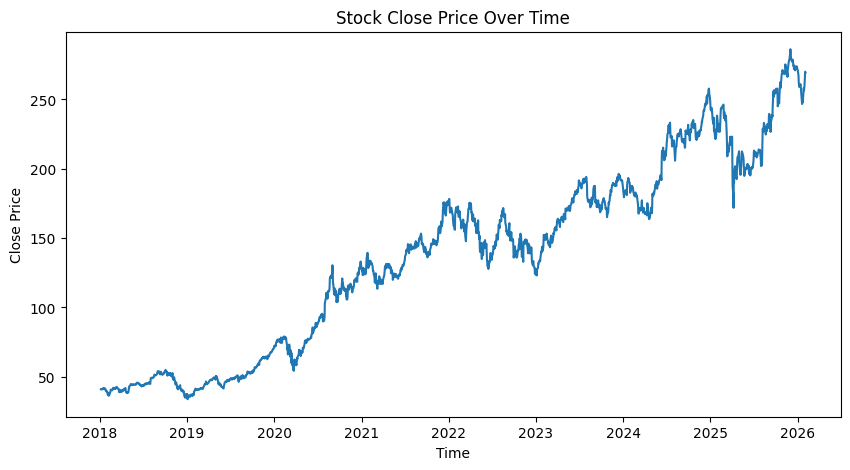

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Close Price Over Time")
plt.show()

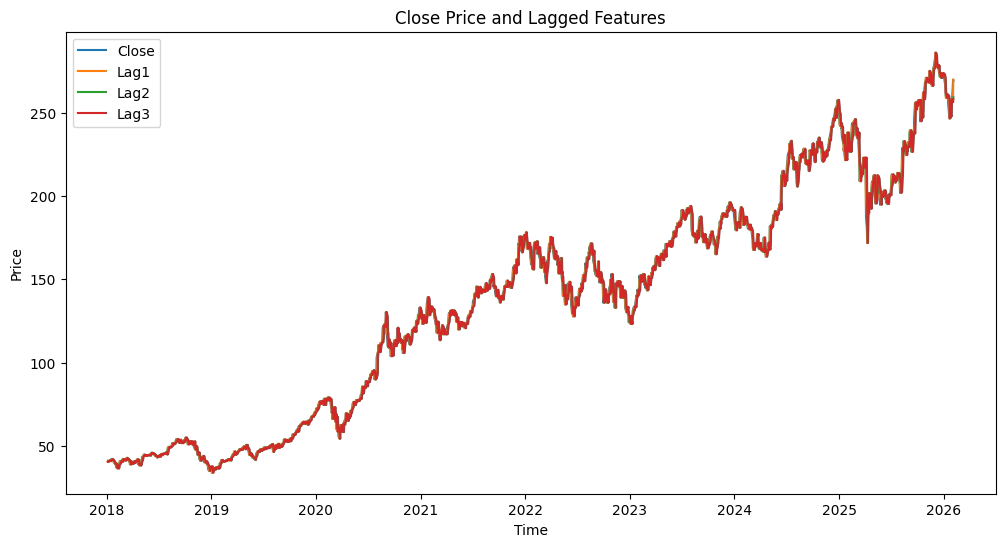

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['Lag1'], label='Lag1')
plt.plot(df['Lag2'], label='Lag2')
plt.plot(df['Lag3'], label='Lag3')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Close Price and Lagged Features")
plt.legend()
plt.show()


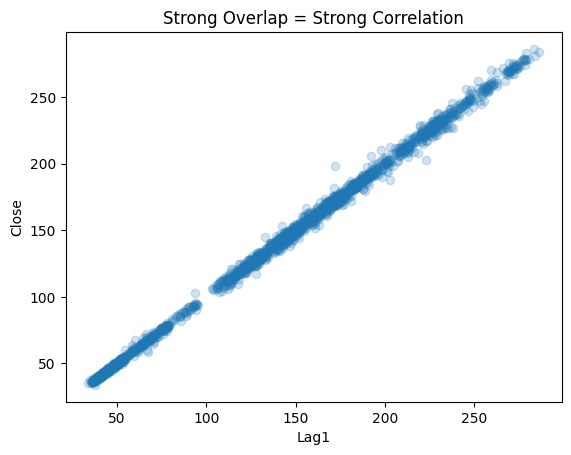

In [10]:
plt.scatter(df['Lag1'], df['Close'], alpha=0.2)

plt.xlabel("Lag1")
plt.ylabel("Close")
plt.title("Strong Overlap = Strong Correlation")
plt.show()


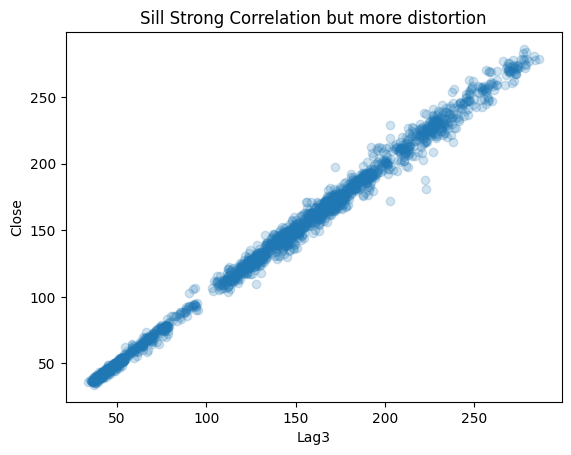

In [15]:
plt.scatter(df['Lag3'], df['Close'], alpha=0.2)

plt.xlabel("Lag3")
plt.ylabel("Close")
plt.title("Sill Strong Correlation but more distortion")
plt.show()

Define X and y

In [19]:
X = df[['Lag1', 'Lag2', 'Lag3']]
y = df['Close']

Train Test split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

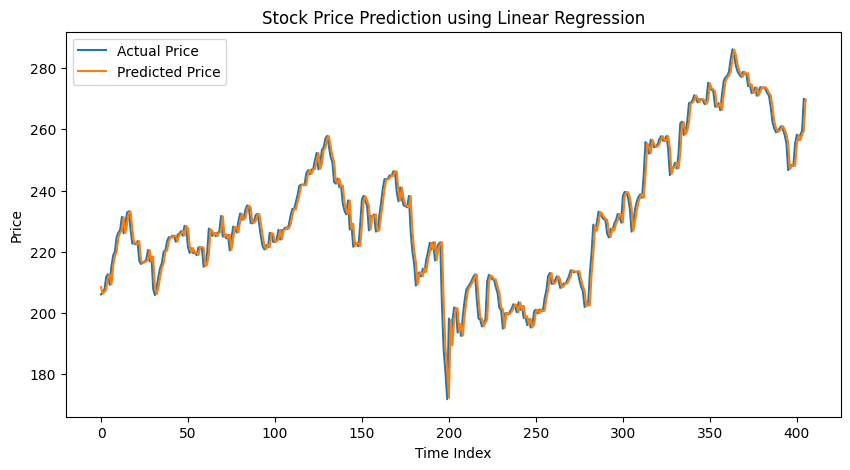

In [24]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.legend()
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()
